# Classificação Supervisionada com KMeans no Dataset Dry Bean (Estrutura Didática Numerada)

Este notebook apresenta um pipeline **didático e numerado** para classificação supervisionada utilizando KMeans no dataset Dry Bean. O objetivo é detalhar cada etapa do processo, desde a importação das bibliotecas até a análise dos resultados, seguindo a mesma estrutura utilizada no notebook do dataset Adult.


A seguir, cada etapa do fluxo é numerada e explicada de forma didática:

1. **Importação das Bibliotecas**
2. **Carregamento e Pré-processamento dos Dados**
3. **Divisão em Treino/Teste**
4. **Definição do Número de Clusters**
5. **Implementação do KMeans Supervisionado**
6. **Treinamento e Avaliação Inicial**
7. **Visualização dos Agrupamentos com PCA**
8. **Repetição dos Experimentos e Análise Estatística**
9. **Análise dos Resultados e Métricas de Avaliação**

Cada seção do notebook está identificada e explicada para facilitar o entendimento do pipeline completo de classificação com KMeans no dataset Dry Bean.

## 1. Importação das Bibliotecas

Importamos as bibliotecas necessárias para manipulação de dados, visualização e implementação do K-Means supervisionado.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os
# Garante que a pasta 'img' existe
os.makedirs('img', exist_ok=True)

## 2. Carregamento e Pré-processamento dos Dados

Carregamos o dataset Dry Bean, removemos valores ausentes, codificamos variáveis categóricas, normalizamos os dados e visualizamos a distribuição da variável alvo. O pré-processamento garante que o KMeans funcione corretamente, pois o algoritmo é sensível à escala dos dados.

In [22]:
# Carregar o dataset Dry Bean
# Certifique-se de que o arquivo está no caminho correto
bean_df = pd.read_excel('data/DryBeanDataset/Dry_Bean_Dataset.xlsx')
bean_df = bean_df.dropna()

print('Amostra dos dados originais:')
display(bean_df.head())



Amostra dos dados originais:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


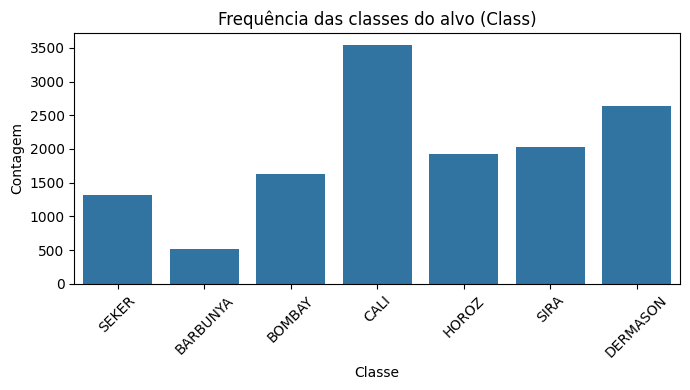

In [23]:
# Codificar variáveis categóricas
for col in bean_df.select_dtypes(include='object').columns:
    bean_df[col] = LabelEncoder().fit_transform(bean_df[col].astype(str))

# Separar features e alvo
X = bean_df.drop('Class', axis=1).values
y = bean_df['Class'].values  # Multiclasse

# Normalizar os dados
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Visualizar frequência das classes do alvo
import seaborn as sns
plt.figure(figsize=(7,4))
class_names = pd.read_excel('data/DryBeanDataset/Dry_Bean_Dataset.xlsx')['Class'].unique()
sns.countplot(x=bean_df['Class'])
plt.title('Frequência das classes do alvo (Class)')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.xticks(ticks=range(len(class_names)), labels=class_names, rotation=45)
plt.tight_layout()
plt.show()

## 3. Divisão em Treino/Teste

Os dados são divididos em conjuntos de treino (70%) e teste (30%) de forma estratificada, preservando a proporção das classes. Isso garante uma avaliação justa do desempenho do modelo em dados não vistos.

In [24]:
# Divisão dos dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

## 4. Definição do Número de Clusters

Definimos o número de clusters a ser utilizado pelo KMeans, com base em conhecimento prévio ou método do cotovelo. Para o dataset Dry Bean, utilizamos 7 clusters, pois há 7 classes distintas.

In [25]:
n_clusters = 10  # Definido pelo método do cotovelo

## 5. Implementação do KMeans Supervisionado

Criação de uma classe que associa cada cluster ao rótulo mais frequente no treino, permitindo avaliação supervisionada. Essa abordagem possibilita avaliar o desempenho do KMeans como classificador, mesmo sendo originalmente um algoritmo não supervisionado.

In [26]:
class KMeansSupervisionado:
    """
    KMeans supervisionado: associa cada cluster ao rótulo mais frequente no treino.
    """
    def __init__(self, n_clusters, random_state=0):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
        self.cluster_labels_ = None

    def fit(self, X, y):
        clusters = self.kmeans.fit_predict(X)
        self.cluster_labels_ = []
        for i in range(self.n_clusters):
            mask = (clusters == i)
            if np.any(mask):
                label = np.bincount(y[mask]).argmax()
            else:
                label = -1
            self.cluster_labels_.append(label)

    def predict(self, X):
        clusters = self.kmeans.predict(X)
        return np.array([self.cluster_labels_[c] for c in clusters])

    def evaluate(self, X, y_true):
        y_pred = self.predict(X)
        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        return acc, cm

## 6. Treinamento e Avaliação Inicial

Treinamento do modelo no conjunto de treino e avaliação inicial no conjunto de teste, incluindo visualização da matriz de confusão. Essa etapa permite verificar como o KMeans supervisionado se comporta na tarefa de classificação multiclasse.

Acurácia: 0.8472
Matriz de Confusão:
[[291   0  70   0   3   5  28]
 [  0 156   1   0   0   0   0]
 [  3   0 475   0   5   1   5]
 [  0   0   3 739   0  32 290]
 [  0   0  67   0 491   0  20]
 [  3   0   0   6   0 549  50]
 [  1   0   8  12   6   5 759]]


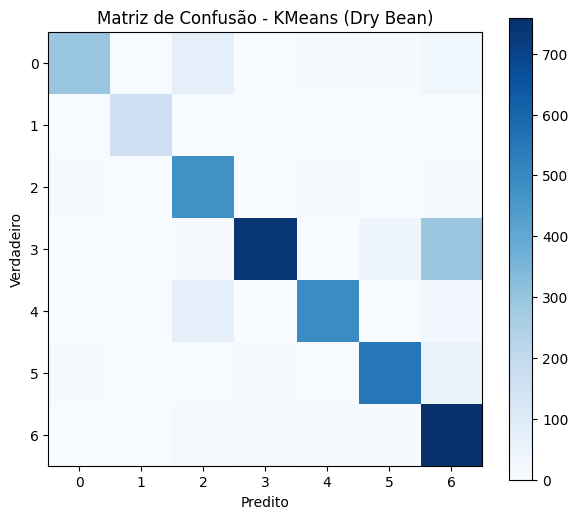

In [27]:
# Treinamento e avaliação
clf = KMeansSupervisionado(n_clusters=n_clusters, random_state=42)
clf.fit(X_train, y_train)
acc, cm = clf.evaluate(X_test, y_test)
print(f'Acurácia: {acc:.4f}')
print('Matriz de Confusão:')
print(cm)

# Visualização da matriz de confusão
plt.figure(figsize=(7,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão - KMeans (Dry Bean)')
plt.colorbar()
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.savefig('img/kmeans_drybean_confusion_matrix.png')
plt.show()

## 7. Visualização dos Agrupamentos com PCA

Redução de dimensionalidade dos dados para 2D usando PCA e visualização dos agrupamentos e centros dos clusters em gráfico de dispersão. Essa visualização facilita a interpretação dos agrupamentos formados pelo KMeans em relação às classes reais.

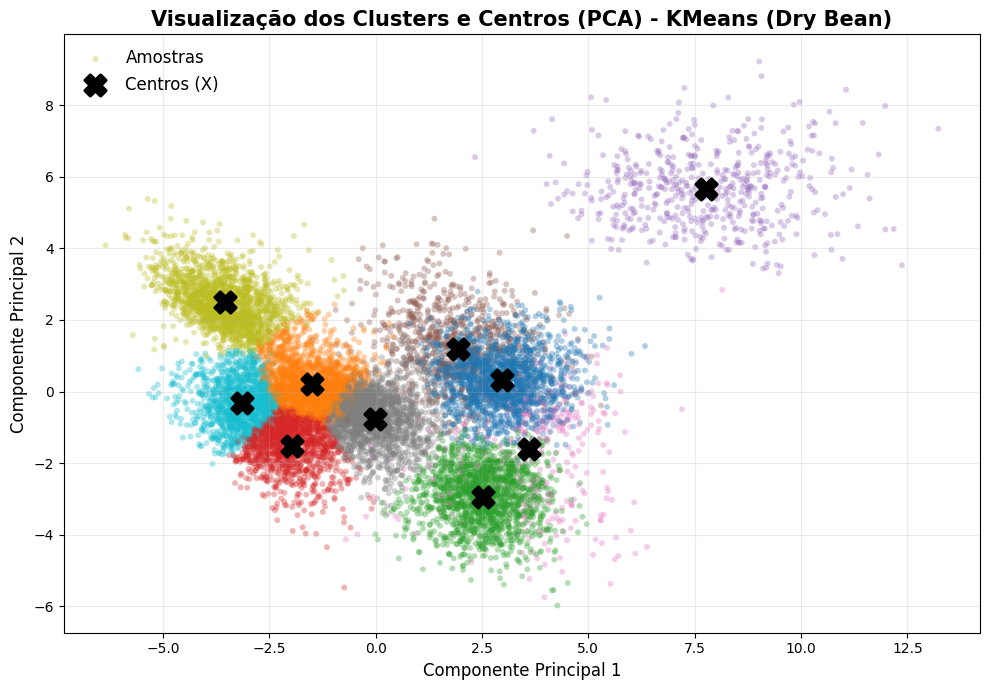

In [28]:
# Redução de dimensionalidade para 2D com PCA e visualização dos clusters
from sklearn.decomposition import PCA

# Aplica PCA para reduzir para 2 componentes principais
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Ajusta o KMeans nos dados completos para obter os clusters e centros
cls = KMeans(n_clusters=n_clusters, random_state=42)
clusters = cls.fit_predict(X)
centros = cls.cluster_centers_
centros_pca = pca.transform(centros)

plt.figure(figsize=(10,7))
plt.scatter(
    X_pca[:,0], X_pca[:,1], 
    c=clusters, cmap='tab10', alpha=0.35, s=18, edgecolor='none', label='Amostras'
    )
plt.scatter(
    centros_pca[:,0], centros_pca[:,1], 
    c='black', marker='X', s=220, linewidths=2.5, zorder=4, label='Centros (X)'
    )
plt.title('Visualização dos Clusters e Centros (PCA) - KMeans (Dry Bean)', fontsize=15, fontweight='bold')
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.grid(alpha=0.25)
plt.legend(frameon=False, fontsize=12, loc='best')
plt.tight_layout()
plt.savefig('img/kmeans_drybean_clusters_pca.png', dpi=150)
plt.show()

## 8. Repetição dos Experimentos e Análise Estatística

Execução do experimento múltiplas vezes com diferentes seeds, cálculo de métricas agregadas (média, desvio padrão, matriz de confusão média) e geração de gráficos para análise de robustez. Essa etapa avalia a estabilidade do KMeans supervisionado no dataset Dry Bean.

MSE médio: 1.2886
Desvio padrão do MSE: 0.1548
Acurácia média: 0.8341
Desvio padrão da acurácia: 0.0278


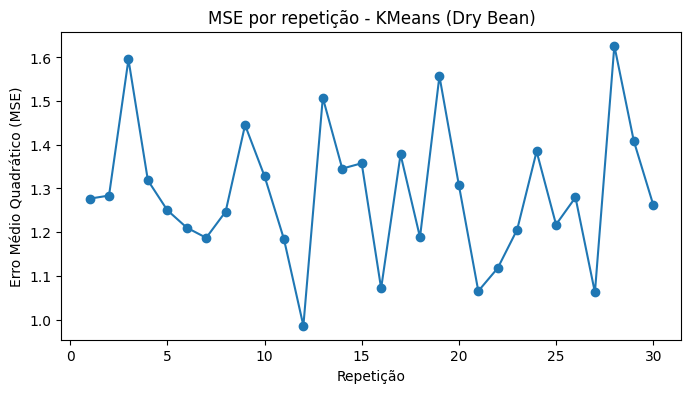

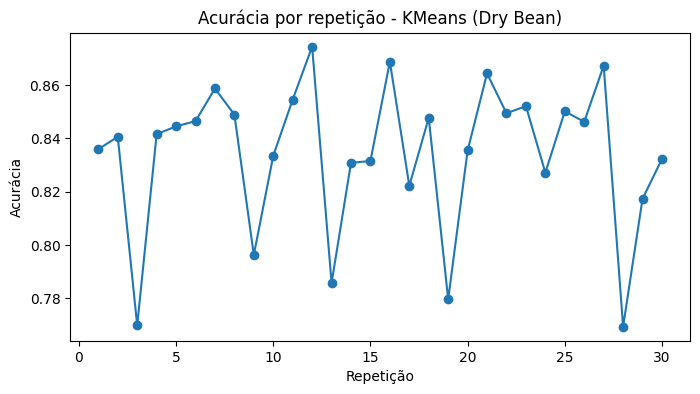

In [29]:
mse_list = []
acuracias = []
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = KMeansSupervisionado(n_clusters=n_clusters, random_state=seed)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_list.append(mse)
    acc, _ = clf.evaluate(X_test, y_test)
    acuracias.append(acc)

mse_array = np.array(mse_list)
acuracias = np.array(acuracias)
print(f'MSE médio: {mse_array.mean():.4f}')
print(f'Desvio padrão do MSE: {mse_array.std():.4f}')
print(f'Acurácia média: {acuracias.mean():.4f}')
print(f'Desvio padrão da acurácia: {acuracias.std():.4f}')

plt.figure(figsize=(8,4))
plt.plot(range(1, 31), mse_array, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Erro Médio Quadrático (MSE)')
plt.title('MSE por repetição - KMeans (Dry Bean)')
plt.savefig('img/kmeans_drybean_mse_repetitions.png')
plt.show()

plt.figure(figsize=(8,4))
plt.plot(range(1,31), acuracias, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Acurácia')
plt.title('Acurácia por repetição - KMeans (Dry Bean)')
plt.savefig('img/kmeans_drybean_accuracy_repetitions.png')
plt.show()

# Salvar MSE e acurácias para análise posterior
np.save('img/kmeans_drybean_mse_repetitions.npy', mse_array)
np.savetxt('img/kmeans_drybean_mse_repetitions.csv', mse_array, delimiter=',')
np.save('img/kmeans_drybean_accuracies.npy', acuracias)
np.savetxt('img/kmeans_drybean_accuracies.csv', acuracias, delimiter=',')

## 9. Análise dos Resultados e Métricas de Avaliação

Discussão dos resultados, explicação das métricas (acurácia, precisão, recall, F1-score) e interpretação da matriz de confusão média. Avalie a correspondência entre clusters e classes, estabilidade do método e possíveis limitações do KMeans para dados multiclasse.

Os resultados do classificador KMeans supervisionado no dataset Dry Bean mostram como o algoritmo consegue identificar padrões em dados multiclasse e de alta dimensionalidade, mesmo sem utilizar rótulos durante o agrupamento.

- **Acurácia média:** O valor apresentado indica o quanto os clusters encontrados se aproximam das classes reais. Em agrupamento, valores intermediários são comuns devido à natureza não supervisionada e à possível sobreposição entre as classes.
- **Desvio padrão:** Um desvio padrão baixo sugere estabilidade do método em diferentes inicializações. Se for alto, pode ser interessante testar mais iterações, diferentes valores de clusters ou técnicas de inicialização.
- **Matriz de confusão:** Permite analisar a correspondência entre clusters e classes. Em agrupamento, é esperado que haja trocas de rótulos, mas padrões diagonais sugerem boa separação.
- **MSE:** O erro médio quadrático complementa a análise da acurácia, mostrando o quanto as previsões se afastam dos rótulos reais.

**Dificuldades comuns:**
- O KMeans pode ser sensível à inicialização e ao número de clusters.
- Em dados com classes desbalanceadas ou sobrepostas, a correspondência entre clusters e classes pode ser limitada.
- O algoritmo não lida bem com clusters de formatos não esféricos ou de tamanhos muito diferentes.

**Sugestão:** Compare os resultados do KMeans com os obtidos por métodos fuzzy (como Fuzzy C-Means ou Gustafson-Kessel) para avaliar qual abordagem é mais adequada para o seu problema.

Acurácia global: 0.8341
Precisão (macro): 0.8742
Recall (macro): 0.8486
F1-score (macro): 0.8529
Matriz de Confusão Média:
[[ 7462     0  3435    43   113    87   770]
 [    5  4700     5     0     0     0     0]
 [  180     0 13811    13   381    11   274]
 [   10     0    84 25256    61   738  5771]
 [    1     0  1651    35 15223     0   430]
 [   73     0    18  1555     1 15692   901]
 [   35     0   238  2846   481    81 20049]]


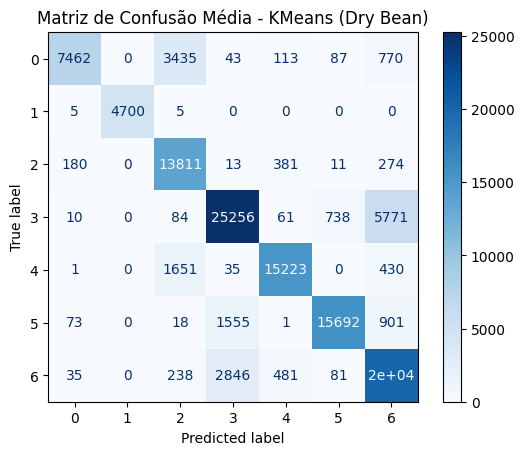

In [30]:
# Cálculo e exibição das principais métricas de avaliação (multiclasse)
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

n_repeats = 30
y_true_all = []
y_pred_all = []
for seed in range(1, n_repeats+1):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = KMeansSupervisionado(n_clusters=n_clusters, random_state=seed)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)

acc = accuracy_score(y_true_all, y_pred_all)
prec = precision_score(y_true_all, y_pred_all, average='macro')
rec = recall_score(y_true_all, y_pred_all, average='macro')
f1 = f1_score(y_true_all, y_pred_all, average='macro')
cm = confusion_matrix(y_true_all, y_pred_all)

print(f"Acurácia global: {acc:.4f}")
print(f"Precisão (macro): {prec:.4f}")
print(f"Recall (macro): {rec:.4f}")
print(f"F1-score (macro): {f1:.4f}")
print("Matriz de Confusão Média:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão Média - KMeans (Dry Bean)')
plt.show()